## ECON4060H 2021 Winter
## Quantitative Methods in Economics
### Week 3 Companion for nonlinear optimization
### Shutao Cao

## 1 Unconstrained optimization

<a id='index-1'></a>


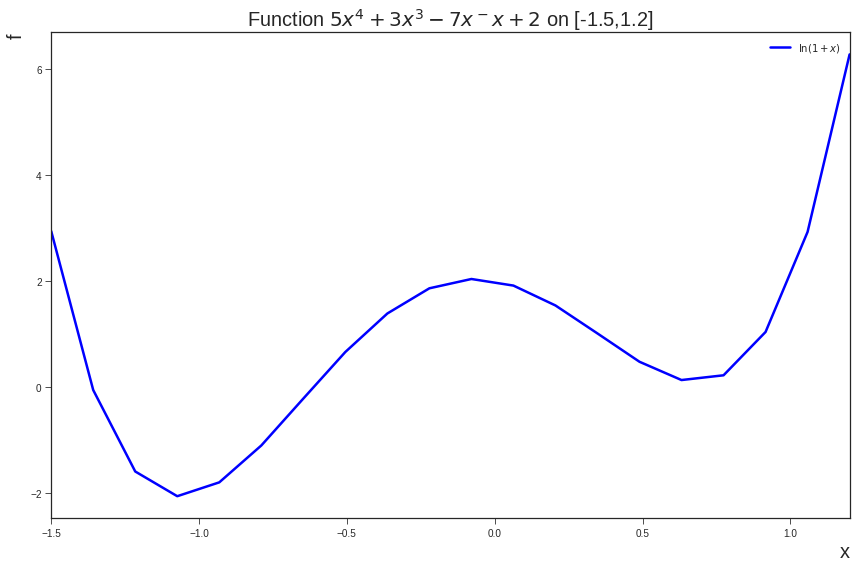

Optimization terminated successfully.
         Current function value: 0.095471
         Iterations: 28
         Function evaluations: 56
Optimization terminated successfully.
         Current function value: -2.066116
         Iterations: 24
         Function evaluations: 48


In [3]:
import math
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-ticks')

#---a function with two local minimals
x = np.linspace(-1.5, 1.2, num=20, endpoint=True)
ffun = lambda x: 5.0*x**4 + 3.0*x**3 - 7.0*x**2 - x + 2.0
lwidth=2.5
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(x, ffun(x), color="blue", linewidth=lwidth, linestyle="-",label="$\ln (1+x)$")
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title("Function $5x^4+3x^3-7x^-x+2$ on [-1.5,1.2]", fontsize=20)
plt.xlabel("x", loc='right',fontsize=20)
ax.set_ylabel("f", loc='top',fontsize=20)
ax.legend(loc='best')
fig.tight_layout()
plt.show()


##---derivative free methods
from scipy.optimize import minimize_scalar
xminBrent = minimize_scalar(ffun, bounds=(-1.5,0,1.2), method='brent')
xminGolden = minimize_scalar(ffun, bounds=(-1.5,-1.0,-0.5), method='golden')
xminBounded = minimize_scalar(ffun, bounds=(-1.5,-0.5), method='bounded')
xminBounded2 = minimize_scalar(ffun, bounds=(-1.5,1.5), method='bounded')


##---Simplex method, local minimization
from scipy.optimize import minimize
x0 = 1.0
xminNM = minimize(ffun, x0, method='nelder-mead', options={'xatol': 1e-8, 'disp': True})
x0 = -1.0
xminNM2 = minimize(ffun, x0, method='nelder-mead', options={'xatol': 1e-8, 'disp': True})

##---BFGS, requires derivative
f_der = lambda x: 20.0*x**3 + 9.0*x**2 - 14.0*x -1.0
x0=1.0
xminBFGS = minimize(ffun, x0, method='BFGS', jac = f_der)
